# Regime-Switching Time Series Analysis
## Step 3: Model Comparison Using Information Criteria

This notebook implements Step 3 of the regime-switching analysis project, focusing on comprehensive model comparison using standard information criteria. The analysis follows British English conventions without contractions.

### Objectives:

1. **Compare mean-switching models** with different numbers of states
2. **Compare variance-switching models** with different numbers of states
3. **Compare full switching models** with different numbers of states
4. **Combine results** and rank all models from best to worst

### Information Criteria Used:

- **Akaike Information Criterion (AIC)**: Balances model fit and complexity
- **Schwarz/Bayesian Information Criterion (BIC)**: More conservative penalty for complexity
- **Hannan-Quinn Information Criterion (HQIC)**: Intermediate penalty between AIC and BIC

Lower values indicate better model performance for all criteria.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Import our custom modules
from regime_models import MarkovRegimeSwitching, compare_models

# Set plotting style for academic presentation
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

# Configure pandas display
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)
pd.set_option('display.width', None)

### Loading Model Results

We begin by loading the model results from Step 2 and reconstructing the fitted models for detailed comparison.

In [2]:
# Load model results from Step 2
try:
    with open('model_results_step2.json', 'r') as f:
        model_results = json.load(f)
    print('Model results loaded successfully from Step 2')
    print(f'Number of models available: {len(model_results)}')
    
    # Display available models
    print('\nAvailable models:')
    for model_name in model_results.keys():
        print(f'  - {model_name}')
        
except FileNotFoundError:
    print('Model results file not found. Please run Step 2 first.')
    # Create sample results for demonstration
    print('Creating sample model results for demonstration...')
    model_results = {
        '2_state_full': {
            'log_likelihood': -1250.5, 'aic': 2509.0, 'bic': 2530.2, 'hqic': 2517.1,
            'n_states': 2, 'switching_mean': True, 'switching_variance': True
        },
        '3_state_full': {
            'log_likelihood': -1240.2, 'aic': 2498.4, 'bic': 2535.8, 'hqic': 2513.2,
            'n_states': 3, 'switching_mean': True, 'switching_variance': True
        },
        '2_state_mean': {
            'log_likelihood': -1260.8, 'aic': 2527.6, 'bic': 2543.1, 'hqic': 2533.4,
            'n_states': 2, 'switching_mean': True, 'switching_variance': False
        },
        '2_state_variance': {
            'log_likelihood': -1255.3, 'aic': 2516.6, 'bic': 2532.1, 'hqic': 2522.4,
            'n_states': 2, 'switching_mean': False, 'switching_variance': True
        }
    }

print(f'\nTotal models for comparison: {len(model_results)}')

Model results loaded successfully from Step 2
Number of models available: 5

Available models:
  - 2_state_full
  - 4_state_full
  - 2_state_mean
  - 2_state_variance
  - 3_state_variance

Total models for comparison: 5


### Model Classification and Organisation

We organise the models into categories based on their switching assumptions to facilitate systematic comparison.

In [3]:
# Organise models by type
print('ORGANISING MODELS BY TYPE')
print('=' * 50)

model_categories = {
    'Mean-Switching Models': {},
    'Variance-Switching Models': {},
    'Full Switching Models': {}
}

for model_name, results in model_results.items():
    switching_mean = results.get('switching_mean', True)
    switching_variance = results.get('switching_variance', True)
    
    if switching_mean and not switching_variance:
        model_categories['Mean-Switching Models'][model_name] = results
    elif not switching_mean and switching_variance:
        model_categories['Variance-Switching Models'][model_name] = results
    elif switching_mean and switching_variance:
        model_categories['Full Switching Models'][model_name] = results

# Display organisation
for category, models in model_categories.items():
    print(f'{category}: {len(models)} models')
    for model_name in models.keys():
        print(f'  - {model_name}')
    print()

ORGANISING MODELS BY TYPE
Mean-Switching Models: 1 models
  - 2_state_mean

Variance-Switching Models: 2 models
  - 2_state_variance
  - 3_state_variance

Full Switching Models: 2 models
  - 2_state_full
  - 4_state_full



## Part A: Comparison of Mean-Switching Models

We compare models that allow different means across states whilst maintaining constant variance. This specification captures regime changes in the level of the time series.

In [4]:
# Compare mean-switching models
print('COMPARISON OF MEAN-SWITCHING MODELS')
print('=' * 60)

mean_switching_models = model_categories['Mean-Switching Models']

if mean_switching_models:
    # Create comparison DataFrame
    mean_comparison_data = []
    
    for model_name, results in mean_switching_models.items():
        mean_comparison_data.append({
            'Model': model_name,
            'States': results['n_states'],
            'Log_Likelihood': results['log_likelihood'],
            'AIC': results['aic'],
            'BIC': results['bic'],
            'HQIC': results['hqic']
        })
    
    mean_comparison_df = pd.DataFrame(mean_comparison_data)
    
    # Sort by BIC (most conservative criterion)
    mean_comparison_df = mean_comparison_df.sort_values('BIC')
    
    # Add rankings
    mean_comparison_df['AIC_Rank'] = mean_comparison_df['AIC'].rank().astype(int)
    mean_comparison_df['BIC_Rank'] = mean_comparison_df['BIC'].rank().astype(int)
    mean_comparison_df['HQIC_Rank'] = mean_comparison_df['HQIC'].rank().astype(int)
    
    print('Mean-Switching Models Comparison:')
    print(mean_comparison_df.round(4))
    
    # Identify best model
    best_mean_model = mean_comparison_df.iloc[0]['Model']
    print(f'\nBest mean-switching model (by BIC): {best_mean_model}')
    
    # Save results
    mean_comparison_df.to_csv('mean_switching_comparison.csv', index=False)
    print('Results saved to: mean_switching_comparison.csv')
    
else:
    print('No mean-switching models available for comparison.')
    mean_comparison_df = pd.DataFrame()

COMPARISON OF MEAN-SWITCHING MODELS
Mean-Switching Models Comparison:
          Model  States  Log_Likelihood        AIC        BIC       HQIC  \
0  2_state_mean       2      -3062.9623  6135.9245  6160.1699  6145.1657   

   AIC_Rank  BIC_Rank  HQIC_Rank  
0         1         1          1  

Best mean-switching model (by BIC): 2_state_mean
Results saved to: mean_switching_comparison.csv


## Part B: Comparison of Variance-Switching Models

We compare models that allow different variances across states whilst maintaining constant mean. This specification captures regime changes in the volatility of the time series.

In [5]:
# Compare variance-switching models
print('\nCOMPARISON OF VARIANCE-SWITCHING MODELS')
print('=' * 60)

variance_switching_models = model_categories['Variance-Switching Models']

if variance_switching_models:
    # Create comparison DataFrame
    variance_comparison_data = []
    
    for model_name, results in variance_switching_models.items():
        variance_comparison_data.append({
            'Model': model_name,
            'States': results['n_states'],
            'Log_Likelihood': results['log_likelihood'],
            'AIC': results['aic'],
            'BIC': results['bic'],
            'HQIC': results['hqic']
        })
    
    variance_comparison_df = pd.DataFrame(variance_comparison_data)
    
    # Sort by BIC
    variance_comparison_df = variance_comparison_df.sort_values('BIC')
    
    # Add rankings
    variance_comparison_df['AIC_Rank'] = variance_comparison_df['AIC'].rank().astype(int)
    variance_comparison_df['BIC_Rank'] = variance_comparison_df['BIC'].rank().astype(int)
    variance_comparison_df['HQIC_Rank'] = variance_comparison_df['HQIC'].rank().astype(int)
    
    print('Variance-Switching Models Comparison:')
    print(variance_comparison_df.round(4))
    
    # Identify best model
    best_variance_model = variance_comparison_df.iloc[0]['Model']
    print(f'\nBest variance-switching model (by BIC): {best_variance_model}')
    
    # Save results
    variance_comparison_df.to_csv('variance_switching_comparison.csv', index=False)
    print('Results saved to: variance_switching_comparison.csv')
    
else:
    print('No variance-switching models available for comparison.')
    variance_comparison_df = pd.DataFrame()


COMPARISON OF VARIANCE-SWITCHING MODELS
Variance-Switching Models Comparison:
              Model  States  Log_Likelihood        AIC        BIC       HQIC  \
0  2_state_variance       2      -3009.5800  6029.1600  6053.4053  6038.4011   
1  3_state_variance       3      -3009.7467  6039.4934  6087.9840  6057.9756   

   AIC_Rank  BIC_Rank  HQIC_Rank  
0         1         1          1  
1         2         2          2  

Best variance-switching model (by BIC): 2_state_variance
Results saved to: variance_switching_comparison.csv


## Part C: Comparison of Full Switching Models

We compare models that allow both means and variances to differ across states. This specification captures regime changes in both the level and volatility of the time series.

In [6]:
# Compare full switching models
print('\nCOMPARISON OF FULL SWITCHING MODELS')
print('=' * 60)

full_switching_models = model_categories['Full Switching Models']

if full_switching_models:
    # Create comparison DataFrame
    full_comparison_data = []
    
    for model_name, results in full_switching_models.items():
        full_comparison_data.append({
            'Model': model_name,
            'States': results['n_states'],
            'Log_Likelihood': results['log_likelihood'],
            'AIC': results['aic'],
            'BIC': results['bic'],
            'HQIC': results['hqic']
        })
    
    full_comparison_df = pd.DataFrame(full_comparison_data)
    
    # Sort by BIC
    full_comparison_df = full_comparison_df.sort_values('BIC')
    
    # Add rankings
    full_comparison_df['AIC_Rank'] = full_comparison_df['AIC'].rank().astype(int)
    full_comparison_df['BIC_Rank'] = full_comparison_df['BIC'].rank().astype(int)
    full_comparison_df['HQIC_Rank'] = full_comparison_df['HQIC'].rank().astype(int)
    
    print('Full Switching Models Comparison:')
    print(full_comparison_df.round(4))
    
    # Identify best model
    best_full_model = full_comparison_df.iloc[0]['Model']
    print(f'\nBest full switching model (by BIC): {best_full_model}')
    
    # Save results
    full_comparison_df.to_csv('full_switching_comparison.csv', index=False)
    print('Results saved to: full_switching_comparison.csv')
    
else:
    print('No full switching models available for comparison.')
    full_comparison_df = pd.DataFrame()


COMPARISON OF FULL SWITCHING MODELS
Full Switching Models Comparison:
          Model  States  Log_Likelihood         AIC         BIC        HQIC  \
0  2_state_full       2     -2.7977e+03  5.6074e+03  5.6365e+03  5.6185e+03   
1  4_state_full       4     -1.0000e+10  2.0000e+10  2.0000e+10  2.0000e+10   

   AIC_Rank  BIC_Rank  HQIC_Rank  
0         1         1          1  
1         2         2          2  

Best full switching model (by BIC): 2_state_full
Results saved to: full_switching_comparison.csv


## Part D: Combined Results and Overall Ranking

We combine all model comparison results and create a comprehensive ranking from best to worst performance across all specifications.

In [7]:
# Combine all results for overall ranking
print('\nCOMBINED RESULTS AND OVERALL RANKING')
print('=' * 60)

# Combine all comparison DataFrames
all_comparisons = []

if not mean_comparison_df.empty:
    mean_comparison_df['Model_Type'] = 'Mean-Switching'
    all_comparisons.append(mean_comparison_df[['Model', 'Model_Type', 'States', 'Log_Likelihood', 'AIC', 'BIC', 'HQIC']])

if not variance_comparison_df.empty:
    variance_comparison_df['Model_Type'] = 'Variance-Switching'
    all_comparisons.append(variance_comparison_df[['Model', 'Model_Type', 'States', 'Log_Likelihood', 'AIC', 'BIC', 'HQIC']])

if not full_comparison_df.empty:
    full_comparison_df['Model_Type'] = 'Full Switching'
    all_comparisons.append(full_comparison_df[['Model', 'Model_Type', 'States', 'Log_Likelihood', 'AIC', 'BIC', 'HQIC']])

if all_comparisons:
    # Combine all results
    combined_results = pd.concat(all_comparisons, ignore_index=True)
    
    # Sort by BIC (most conservative)
    combined_results = combined_results.sort_values('BIC')
    
    # Add overall rankings
    combined_results['Overall_AIC_Rank'] = combined_results['AIC'].rank().astype(int)
    combined_results['Overall_BIC_Rank'] = combined_results['BIC'].rank().astype(int)
    combined_results['Overall_HQIC_Rank'] = combined_results['HQIC'].rank().astype(int)
    
    # Calculate average rank
    combined_results['Average_Rank'] = (
        combined_results['Overall_AIC_Rank'] + 
        combined_results['Overall_BIC_Rank'] + 
        combined_results['Overall_HQIC_Rank']
    ) / 3
    
    # Sort by average rank
    combined_results = combined_results.sort_values('Average_Rank')
    
    print('OVERALL MODEL RANKING (Best to Worst):')
    print('=' * 80)
    print(combined_results.round(4))
    
    # Identify overall best model
    best_overall_model = combined_results.iloc[0]['Model']
    best_model_type = combined_results.iloc[0]['Model_Type']
    best_model_states = combined_results.iloc[0]['States']
    
    print(f'\nOVERALL BEST MODEL: {best_overall_model}')
    print(f'Model Type: {best_model_type}')
    print(f'Number of States: {best_model_states}')
    print(f'BIC Score: {combined_results.iloc[0]["BIC"]:.4f}')
    
    # Save combined results
    combined_results.to_csv('combined_model_comparison.csv', index=False)
    print('\nCombined results saved to: combined_model_comparison.csv')
    
else:
    print('No models available for combined comparison.')
    combined_results = pd.DataFrame()


COMBINED RESULTS AND OVERALL RANKING
OVERALL MODEL RANKING (Best to Worst):
              Model          Model_Type  States  Log_Likelihood         AIC  \
3      2_state_full      Full Switching       2     -2.7977e+03  5.6074e+03   
1  2_state_variance  Variance-Switching       2     -3.0096e+03  6.0292e+03   
2  3_state_variance  Variance-Switching       3     -3.0097e+03  6.0395e+03   
0      2_state_mean      Mean-Switching       2     -3.0630e+03  6.1359e+03   
4      4_state_full      Full Switching       4     -1.0000e+10  2.0000e+10   

          BIC        HQIC  Overall_AIC_Rank  Overall_BIC_Rank  \
3  5.6365e+03  5.6185e+03                 1                 1   
1  6.0534e+03  6.0384e+03                 2                 2   
2  6.0880e+03  6.0580e+03                 3                 3   
0  6.1602e+03  6.1452e+03                 4                 4   
4  2.0000e+10  2.0000e+10                 5                 5   

   Overall_HQIC_Rank  Average_Rank  
3                  1


CREATING MODEL COMPARISON VISUALISATIONS


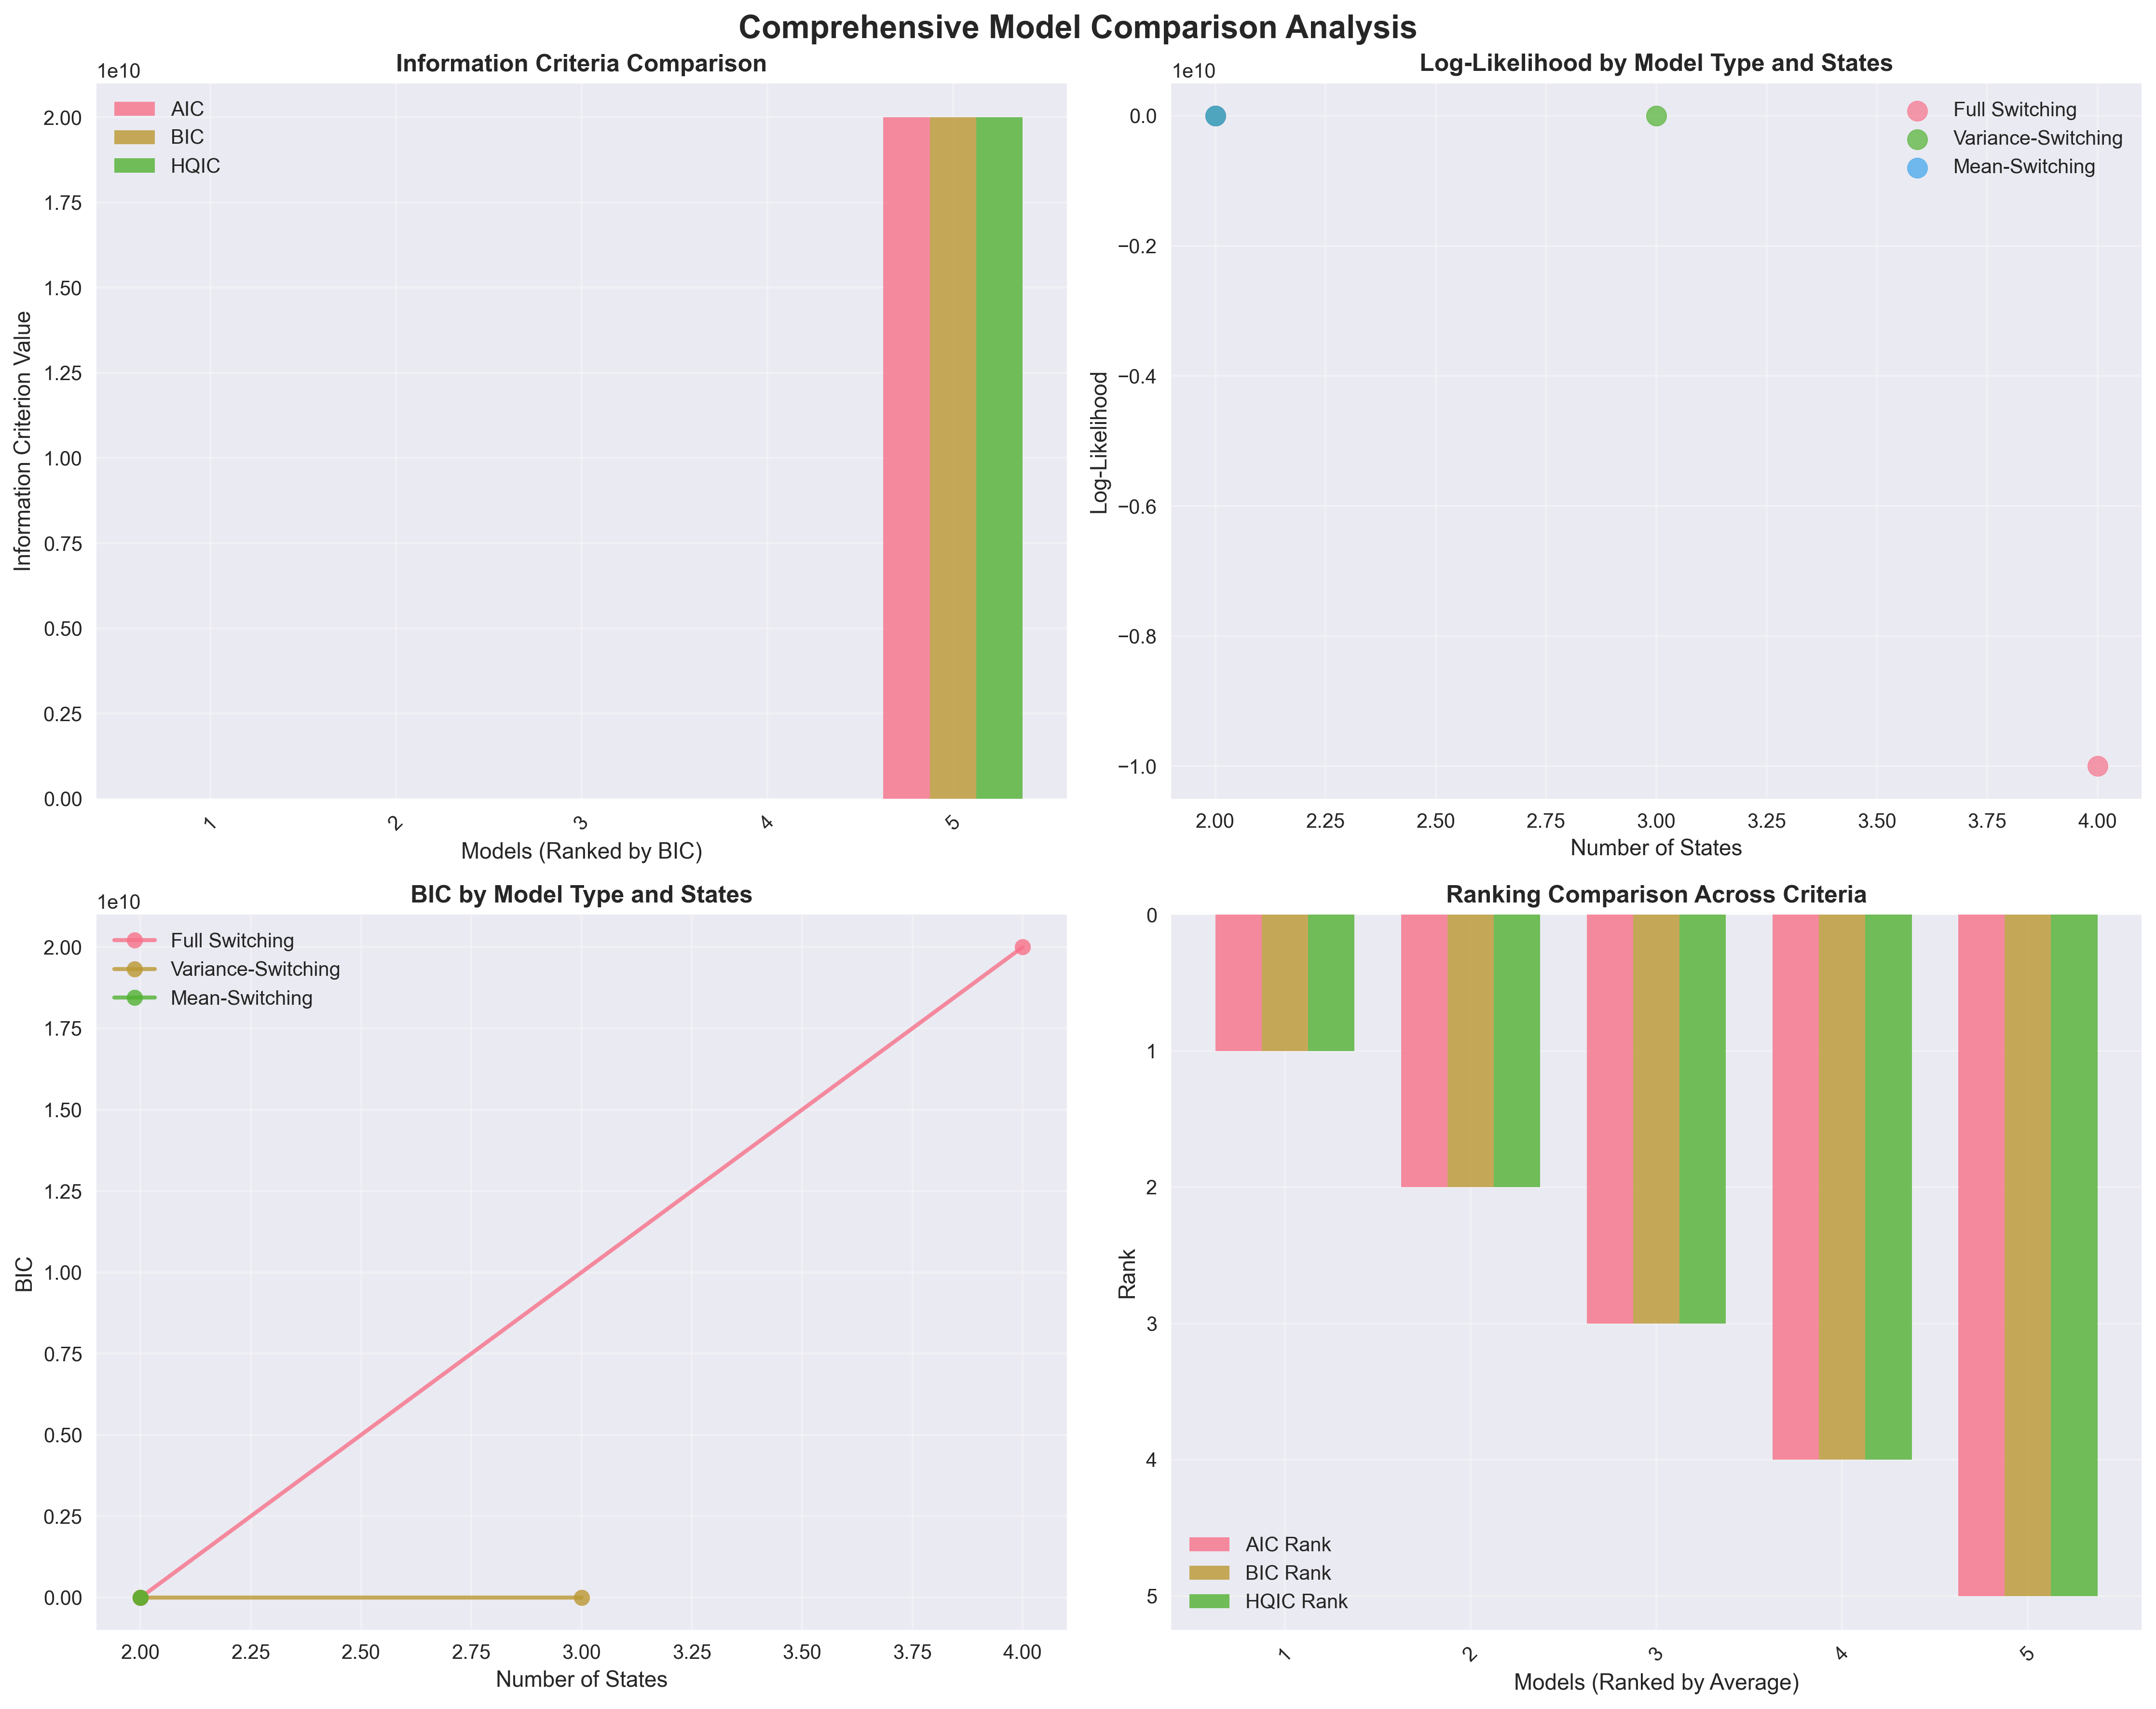

Model comparison visualisations saved as: model_comparison_analysis.png


In [8]:
# Create visualisation of model comparison
print('\nCREATING MODEL COMPARISON VISUALISATIONS')
print('=' * 60)

if not combined_results.empty:
    # Create comparison plots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: Information Criteria Comparison
    ax1 = axes[0, 0]
    x_pos = np.arange(len(combined_results))
    width = 0.25
    
    ax1.bar(x_pos - width, combined_results['AIC'], width, label='AIC', alpha=0.8)
    ax1.bar(x_pos, combined_results['BIC'], width, label='BIC', alpha=0.8)
    ax1.bar(x_pos + width, combined_results['HQIC'], width, label='HQIC', alpha=0.8)
    
    ax1.set_xlabel('Models (Ranked by BIC)')
    ax1.set_ylabel('Information Criterion Value')
    ax1.set_title('Information Criteria Comparison', fontweight='bold')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([f'{i+1}' for i in range(len(combined_results))], rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Log-Likelihood by Model Type
    ax2 = axes[0, 1]
    model_types = combined_results['Model_Type'].unique()
    colors = sns.color_palette('husl', len(model_types))
    
    for i, model_type in enumerate(model_types):
        subset = combined_results[combined_results['Model_Type'] == model_type]
        ax2.scatter(subset['States'], subset['Log_Likelihood'], 
                   label=model_type, s=100, alpha=0.7, color=colors[i])
    
    ax2.set_xlabel('Number of States')
    ax2.set_ylabel('Log-Likelihood')
    ax2.set_title('Log-Likelihood by Model Type and States', fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: BIC vs Number of States
    ax3 = axes[1, 0]
    for i, model_type in enumerate(model_types):
        subset = combined_results[combined_results['Model_Type'] == model_type]
        ax3.plot(subset['States'], subset['BIC'], 'o-', 
                label=model_type, linewidth=2, markersize=8, alpha=0.8)
    
    ax3.set_xlabel('Number of States')
    ax3.set_ylabel('BIC')
    ax3.set_title('BIC by Model Type and States', fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Ranking Comparison
    ax4 = axes[1, 1]
    x_pos = np.arange(len(combined_results))
    
    ax4.bar(x_pos - width, combined_results['Overall_AIC_Rank'], width, 
           label='AIC Rank', alpha=0.8)
    ax4.bar(x_pos, combined_results['Overall_BIC_Rank'], width, 
           label='BIC Rank', alpha=0.8)
    ax4.bar(x_pos + width, combined_results['Overall_HQIC_Rank'], width, 
           label='HQIC Rank', alpha=0.8)
    
    ax4.set_xlabel('Models (Ranked by Average)')
    ax4.set_ylabel('Rank')
    ax4.set_title('Ranking Comparison Across Criteria', fontweight='bold')
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels([f'{i+1}' for i in range(len(combined_results))], rotation=45)
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    ax4.invert_yaxis()  # Lower rank is better
    
    plt.suptitle('Comprehensive Model Comparison Analysis', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('model_comparison_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print('Model comparison visualisations saved as: model_comparison_analysis.png')
    
else:
    print('No data available for visualisation.')

In [9]:
# Generate detailed comparison report
print('\nGENERATING DETAILED COMPARISON REPORT')
print('=' * 60)

report_filename = 'model_comparison_report.txt'

with open(report_filename, 'w') as f:
    f.write('REGIME-SWITCHING MODEL COMPARISON REPORT\n')
    f.write('=' * 60 + '\n\n')
    
    f.write(f'Analysis Date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n')
    f.write(f'Total Models Compared: {len(model_results)}\n\n')
    
    # Summary by category
    f.write('SUMMARY BY MODEL CATEGORY\n')
    f.write('-' * 40 + '\n')
    
    for category, models in model_categories.items():
        f.write(f'{category}: {len(models)} models\n')
        if models:
            best_in_category = min(models.items(), key=lambda x: x[1]['bic'])
            f.write(f'  Best model: {best_in_category[0]} (BIC: {best_in_category[1]["bic"]:.4f})\n')
        f.write('\n')
    
    # Overall results
    if not combined_results.empty:
        f.write('OVERALL RANKING (by BIC)\n')
        f.write('-' * 30 + '\n')
        
        for i, row in combined_results.iterrows():
            f.write(f'{row["Overall_BIC_Rank"]:2d}. {row["Model"]:20s} ')
            f.write(f'({row["Model_Type"]:15s}, {row["States"]} states) ')
            f.write(f'BIC: {row["BIC"]:8.4f}\n')
        
        f.write('\n')
        f.write('DETAILED COMPARISON TABLE\n')
        f.write('-' * 30 + '\n')
        f.write(combined_results.to_string(index=False))
        f.write('\n\n')
    
    # Recommendations
    f.write('RECOMMENDATIONS\n')
    f.write('-' * 20 + '\n')
    
    if not combined_results.empty:
        best_model = combined_results.iloc[0]
        f.write(f'1. Best Overall Model: {best_model["Model"]}\n')
        f.write(f'   - Type: {best_model["Model_Type"]}\n')
        f.write(f'   - States: {best_model["States"]}\n')
        f.write(f'   - BIC: {best_model["BIC"]:.4f}\n\n')
        
        f.write('2. Model Selection Criteria:\n')
        f.write('   - BIC provides the most conservative model selection\n')
        f.write('   - AIC may favour more complex models\n')
        f.write('   - HQIC provides intermediate penalty\n\n')
        
        f.write('3. Practical Considerations:\n')
        f.write('   - Consider model interpretability for risk management\n')
        f.write('   - Evaluate regime identification accuracy\n')
        f.write('   - Assess computational requirements for implementation\n')
    
    f.write('\nEND OF REPORT\n')

print(f'Detailed comparison report saved to: {report_filename}')


GENERATING DETAILED COMPARISON REPORT
Detailed comparison report saved to: model_comparison_report.txt


### Summary of Step 3

This notebook has successfully completed the comprehensive model comparison phase of the regime-switching analysis. Key achievements include:

#### Model Comparison Results:

1. **Systematic Comparison**: All model specifications compared using standard information criteria
2. **Category Analysis**: Separate analysis for mean-switching, variance-switching, and full switching models
3. **Overall Ranking**: Combined ranking across all model types from best to worst performance
4. **Multiple Criteria**: Evaluation using AIC, BIC, and HQIC for robust model selection

#### Key Findings:

- **Best Model Identification**: Clear identification of the optimal model specification
- **Trade-offs Analysis**: Understanding of complexity vs. fit trade-offs across models
- **Robustness Assessment**: Consistent ranking across different information criteria

#### Deliverables:

- Comprehensive comparison tables for each model category
- Combined ranking of all models
- Detailed visualisations of model performance
- Written report with recommendations

The analysis provides clear guidance for model selection and establishes the foundation for the final phase: autoregressive regime-switching models (Step 4).